# COM7019 – Artificial Intelligence and Neural Networks
## Task 1: Sentiment Analysis System Development and Implementation

**Student ID:** STU96523  
**Dataset:** Amazon Reviews 2023 – Electronics

1. Import Libraries

In [ ]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualisation
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


2. Load the dataset

In [ ]:
import glob

csv_files = glob.glob("*.csv")
print(csv_files)

['Amazon_Reviews_2023_Electronics – COM7019 - [3922].csv']


In [ ]:
df = pd.read_csv(csv_files[0])

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (50000, 4)


3. Initial Data Exploration

In [ ]:
df.head()

,rating,title,text,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,True
2,5.0,Excellent!,I love these. They even come with a carry case...,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,True


In [ ]:
print(df.columns.tolist())

['rating', 'title', 'text', 'verified_purchase']


4. Examine the dataset structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             50000 non-null  float64
 1   title              49995 non-null  object 
 2   text               49998 non-null  object 
 3   verified_purchase  50000 non-null  bool   
dtypes: bool(1), float64(1), object(2)
memory usage: 1.2+ MB


5. Check missing values

In [ ]:
print(df.isnull().sum())

rating               0
title                5
text                 2
verified_purchase    0
dtype: int64


6. Check duplicate reviews

In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 1494


7. Investigate the ratings

In [ ]:
rating_counts = df["rating"].value_counts().sort_index()

print(rating_counts)

rating
1.0     4144
2.0     2116
3.0     3412
4.0     7381
5.0    32947
Name: count, dtype: int64


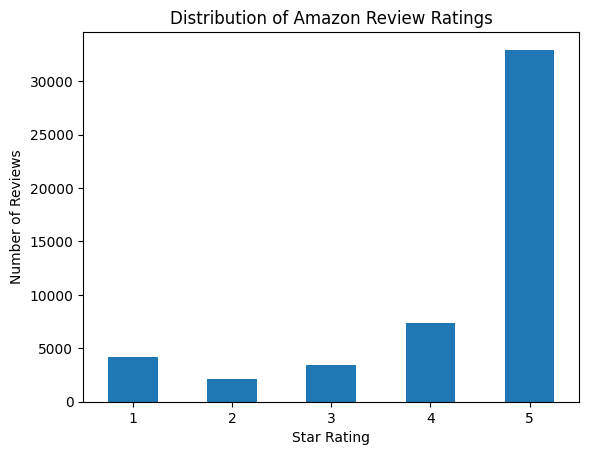

In [ ]:
rating_counts.plot(kind="bar")

plt.title("Distribution of Amazon Review Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1, 2, 3, 4], [1, 2, 3, 4, 5], rotation=0)
plt.show()

8.1 Remove duplicate rows

In [ ]:
# Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

print("Original number of rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Original number of rows: 50000
Rows after removing duplicates: 48506
Duplicates removed: 1494


8.2 Handle missing values

In [ ]:
# Check missing values after duplicate removal
print("Missing values in the cleaned dataset:")
print(df_clean.isnull().sum())

Missing values in the cleaned dataset:
rating               0
title                5
text                 2
verified_purchase    0
dtype: int64


In [ ]:
# Display rows containing missing title or text values
missing_rows = df_clean[
    df_clean["title"].isnull() | df_clean["text"].isnull()
]

missing_rows

,rating,title,text,verified_purchase
8046,1.0,NaN,NaN,True
8991,5.0,NaN,Great production,True
10403,1.0,NaN,Returned item,True
10725,5.0,NaN,NaN,True
49355,1.0,NaN,No yood,True


8.3 Handle the missing text appropriately

In [ ]:
# Replace missing title and text values with empty strings
df_clean["title"] = df_clean["title"].fillna("")
df_clean["text"] = df_clean["text"].fillna("")

# Check missing values again
print("Missing values after handling:")
print(df_clean.isnull().sum())

Missing values after handling:
rating               0
title                0
text                 0
verified_purchase    0
dtype: int64


In [ ]:
# Remove rows where both title and review text are empty
df_clean = df_clean[
    (df_clean["title"].str.strip() != "") |
    (df_clean["text"].str.strip() != "")
].copy()

print("Rows remaining after removing empty reviews:", len(df_clean))

Rows remaining after removing empty reviews: 48504


9. Create Sentiment Labels

In [ ]:
# Create sentiment labels from star ratings
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df_clean["sentiment"] = df_clean["rating"].apply(create_sentiment)

# Display a sample
df_clean[["rating", "sentiment"]].head(10)

,rating,sentiment
0,3.0,Neutral
1,1.0,Negative
2,5.0,Positive
3,5.0,Positive
4,5.0,Positive
5,5.0,Positive
6,5.0,Positive
7,5.0,Positive
8,5.0,Positive
9,5.0,Positive


9.1 Check the new class distribution

In [ ]:
sentiment_counts = df_clean["sentiment"].value_counts()

print("Sentiment class distribution:")
print(sentiment_counts)

print("\nSentiment percentages:")
print((df_clean["sentiment"].value_counts(normalize=True) * 100).round(2))

Sentiment class distribution:
sentiment
Positive    38874
Negative     6238
Neutral      3392
Name: count, dtype: int64

Sentiment percentages:
sentiment
Positive    80.15
Negative    12.86
Neutral      6.99
Name: proportion, dtype: float64


9.2 Visualise the sentiment distribution

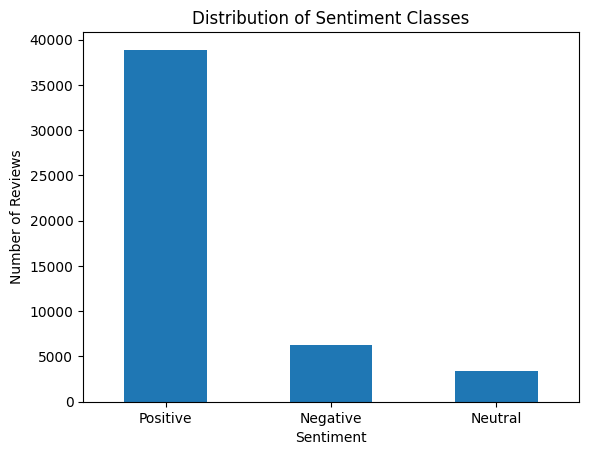

In [ ]:
# Plot sentiment class distribution
sentiment_counts = df_clean["sentiment"].value_counts()

sentiment_counts.plot(kind="bar")

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

10. Combine Review Title and Text

In [ ]:
# Combine review title and main review text
df_clean["review"] = (
    df_clean["title"].str.strip() + " " +
    df_clean["text"].str.strip()
).str.strip()

# Display examples
df_clean[["title", "text", "review"]].head()

,title,text,review
0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,Smells like gasoline! Going back! First & most...
1,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,Didn’t work at all lenses loose/broken. These ...
2,Excellent!,I love these. They even come with a carry case...,Excellent! I love these. They even come with a...
3,Great laptop backpack!,I was searching for a sturdy backpack for scho...,Great laptop backpack! I was searching for a s...
4,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,Best Headphones in the Fifties price range! I'...


10.1 Examine Review Lengths

In [ ]:
# Calculate review length in words
df_clean["word_count"] = df_clean["review"].str.split().str.len()

print(df_clean["word_count"].describe())

count    48504.000000
mean        74.779132
std        107.442620
min          2.000000
25%         17.000000
50%         40.000000
75%         86.000000
max       2044.000000
Name: word_count, dtype: float64


In [ ]:
# Display selected percentiles of review length
print("50th percentile:", df_clean["word_count"].quantile(0.50))
print("75th percentile:", df_clean["word_count"].quantile(0.75))
print("90th percentile:", df_clean["word_count"].quantile(0.90))
print("95th percentile:", df_clean["word_count"].quantile(0.95))
print("99th percentile:", df_clean["word_count"].quantile(0.99))

50th percentile: 40.0
75th percentile: 86.0
90th percentile: 174.0
95th percentile: 269.0
99th percentile: 536.9700000000012


11. Prepare the data for modelling

In [ ]:
# Encode sentiment labels
label_mapping = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df_clean["label"] = df_clean["sentiment"].map(label_mapping)

# Check the mapping
print(df_clean[["sentiment", "label"]].drop_duplicates().sort_values("label"))

  sentiment  label
1  Negative      0
0   Neutral      1
2  Positive      2


11.1 Training, Validation and Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean["review"]
y = df_clean["label"]

# 80% training, 20% temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split temporary set equally into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 38803
Validation samples: 4850
Test samples: 4851


11.2 Verify the split

In [ ]:
print("Training class distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation class distribution:")
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training class distribution:
label
2    80.15
0    12.86
1     6.99
Name: proportion, dtype: float64

Validation class distribution:
label
2    80.14
0    12.87
1     6.99
Name: proportion, dtype: float64

Test class distribution:
label
2    80.15
0    12.86
1     6.99
Name: proportion, dtype: float64


12. Text Tokenisation and Sequence Padding

12.1 Configure and Fit the Tokeniser

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Tokenisation settings
vocab_size = 20000
max_length = 200
oov_token = "<OOV>"

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token=oov_token
)

# Learn the vocabulary using ONLY the training data
tokenizer.fit_on_texts(X_train)

12.2 Inspect the vocabulary

In [ ]:
print("Total unique words found:", len(tokenizer.word_index))

print("\nFirst 20 words in the vocabulary:")
print(list(tokenizer.word_index.items())[:20])

Total unique words found: 37558

First 20 words in the vocabulary:
[('<OOV>', 1), ('the', 2), ('i', 3), ('to', 4), ('and', 5), ('a', 6), ('it', 7), ('is', 8), ('br', 9), ('for', 10), ('this', 11), ('of', 12), ('my', 13), ('in', 14), ('with', 15), ('that', 16), ('on', 17), ('you', 18), ('have', 19), ('but', 20)]


12.3 Convert reviews into sequences

In [ ]:
# Convert text into integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Look at one example
print("Original review:")
print(X_train.iloc[0])

print("\nToken sequence:")
print(X_train_seq[0][:50])

Original review:
very helpful great for storage

Token sequence:
[28, 469, 22, 10, 404]


12.4 Pad the sequences

In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_pad.shape)
print("Validation data shape:", X_val_pad.shape)
print("Test data shape:", X_test_pad.shape)

Training data shape: (38803, 200)
Validation data shape: (4850, 200)
Test data shape: (4851, 200)


13. Calculate Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate balanced class weights using the training labels
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

Class weights:
{np.int64(0): np.float64(2.5920507682030727), np.int64(1): np.float64(4.76578236305576), np.int64(2): np.float64(0.4159083357449864)}


14. Baseline Neural Network

14.1 Build the model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Make results more reproducible
tf.random.set_seed(42)

embedding_dim = 64

baseline_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    GlobalAveragePooling1D(),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(3, activation="softmax")
])

baseline_model.build(input_shape=(None, max_length))

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,355 (4.90 MB)

 Trainable params: 1,284,355 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

14.2 Compile the model

In [ ]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline model compiled successfully.")

Baseline model compiled successfully.


15. Train the Baseline Neural Network

15.1 Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

15.2 Train the model

In [ ]:
history_baseline = baseline_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4466 - loss: 1.0711 - val_accuracy: 0.4779 - val_loss: 1.0707
Epoch 2/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7240 - loss: 0.8395 - val_accuracy: 0.6833 - val_loss: 0.7568
Epoch 3/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.7722 - loss: 0.7208 - val_accuracy: 0.7860 - val_loss: 0.5792
Epoch 4/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.7980 - loss: 0.6469 - val_accuracy: 0.7920 - val_loss: 0.5442
Epoch 5/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8160 - loss: 0.5958 - val_accuracy: 0.7994 - val_loss: 0.5201
Epoch 6/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8281 - loss: 0.5513 - val_accuracy: 0.7895 - val_loss: 0.5139
Epoch 7/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8383 - loss: 0.5152 - val_accuracy: 0.8414 - val_loss: 0.3937
Epoch 8/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8467 - loss: 0.4882 - 

15.3 Plot training and validation accuracy

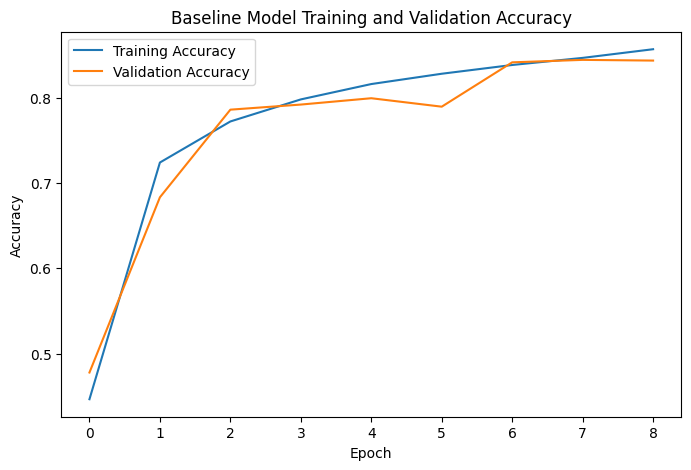

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline Model Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

15.4 Plot training and validation loss

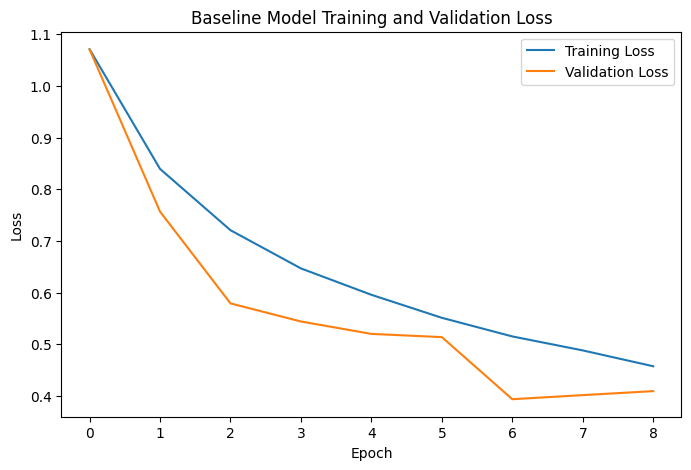

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")

plt.title("Baseline Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

16. Baseline Model Validation Evaluation

16.1 Get validation predictions

In [ ]:
# Predict probabilities for the validation data
y_val_prob_baseline = baseline_model.predict(X_val_pad)

# Convert probabilities to predicted class labels
y_val_pred_baseline = np.argmax(y_val_prob_baseline, axis=1)

print("First 20 predicted labels:")
print(y_val_pred_baseline[:20])

print("\nFirst 20 actual labels:")
print(y_val.iloc[:20].values)

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
First 20 predicted labels:
[2 2 2 2 2 2 1 2 2 2 2 1 2 2 2 2 2 2 2 2]

First 20 actual labels:
[2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2]


16.2 Classification report

In [ ]:
from sklearn.metrics import classification_report

print("Baseline Model - Validation Classification Report:\n")

print(
    classification_report(
        y_val,
        y_val_pred_baseline,
        target_names=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

Baseline Model - Validation Classification Report:

              precision    recall  f1-score   support

    Negative     0.8127    0.4728    0.5978       624
     Neutral     0.2841    0.6077    0.3872       339
    Positive     0.9516    0.9210    0.9361      3887

    accuracy                         0.8414      4850
   macro avg     0.6828    0.6671    0.6404      4850
weighted avg     0.8871    0.8414    0.8542      4850



16.3 Confusion matrix

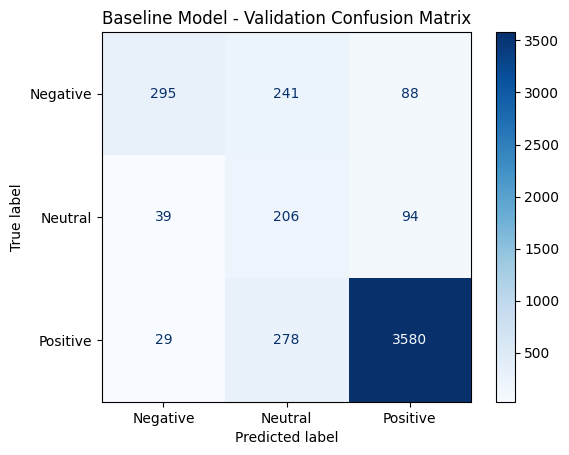

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_baseline = confusion_matrix(y_val, y_val_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(cmap="Blues")
plt.title("Baseline Model - Validation Confusion Matrix")
plt.show()

16.4 Store the Baseline Results

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_accuracy = accuracy_score(y_val, y_val_pred_baseline)

baseline_precision = precision_score(
    y_val,
    y_val_pred_baseline,
    average="macro"
)

baseline_recall = recall_score(
    y_val,
    y_val_pred_baseline,
    average="macro"
)

baseline_f1 = f1_score(
    y_val,
    y_val_pred_baseline,
    average="macro"
)

print("Baseline Validation Metrics")
print("---------------------------")
print(f"Accuracy:        {baseline_accuracy:.4f}")
print(f"Macro Precision: {baseline_precision:.4f}")
print(f"Macro Recall:    {baseline_recall:.4f}")
print(f"Macro F1-score:  {baseline_f1:.4f}")

Baseline Validation Metrics
---------------------------
Accuracy:        0.8414
Macro Precision: 0.6828
Macro Recall:    0.6671
Macro F1-score:  0.6404


17. LSTM Neural Network

17.1 Build the LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Reproducibility
tf.random.set_seed(42)

lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        3,
        activation="softmax"
    )
])

lstm_model.build(input_shape=(None, max_length))

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,379 (5.03 MB)

 Trainable params: 1,317,379 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

17.2 Compile the LSTM

In [ ]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("LSTM model compiled successfully.")

LSTM model compiled successfully.


18. Train the LSTM Model

In [ ]:
early_stopping_lstm = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [ ]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping_lstm],
    verbose=1
)

Epoch 1/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 128s 206ms/step - accuracy: 0.6796 - loss: 0.8566 - val_accuracy: 0.7796 - val_loss: 0.5394
Epoch 2/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 139s 201ms/step - accuracy: 0.7802 - loss: 0.6567 - val_accuracy: 0.8443 - val_loss: 0.4128
Epoch 3/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 121s 200ms/step - accuracy: 0.8299 - loss: 0.5385 - val_accuracy: 0.8159 - val_loss: 0.4971
Epoch 4/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 121s 200ms/step - accuracy: 0.8564 - loss: 0.4573 - val_accuracy: 0.7973 - val_loss: 0.5603


18.1 Plot LSTM accuracy

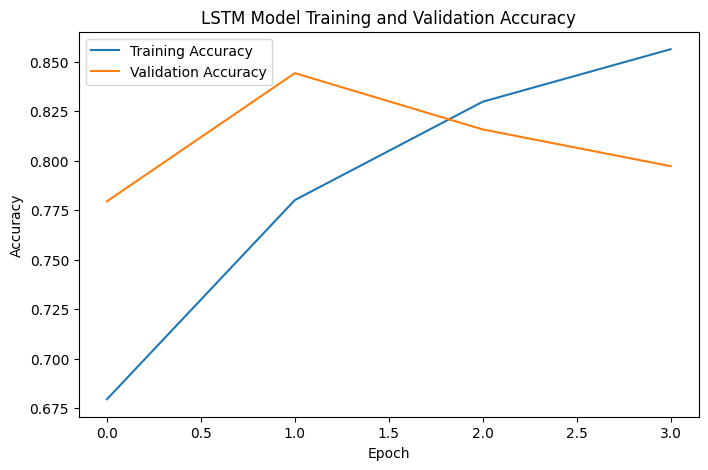

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Model Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

18.2 Plot LSTM loss

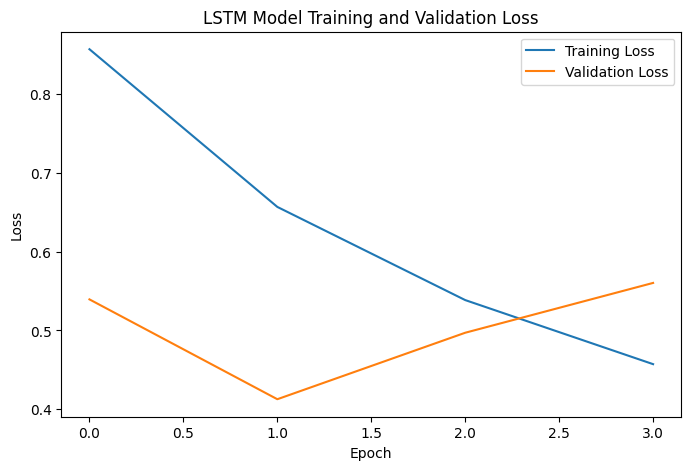

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.title("LSTM Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

19. LSTM Model Validation Evaluation

19.1 Generate predictions

In [ ]:
# Predict probabilities for validation data
y_val_prob_lstm = lstm_model.predict(X_val_pad)

# Convert probabilities to predicted class labels
y_val_pred_lstm = np.argmax(y_val_prob_lstm, axis=1)

print("First 20 predicted labels:")
print(y_val_pred_lstm[:20])

print("\nFirst 20 actual labels:")
print(y_val.iloc[:20].values)

152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step
First 20 predicted labels:
[2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2]

First 20 actual labels:
[2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2]


19.2 Classification report

In [ ]:
print("LSTM Model - Validation Classification Report:\n")

print(
    classification_report(
        y_val,
        y_val_pred_lstm,
        target_names=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

LSTM Model - Validation Classification Report:

              precision    recall  f1-score   support

    Negative     0.7016    0.7196    0.7104       624
     Neutral     0.2926    0.5369    0.3788       339
    Positive     0.9654    0.8912    0.9268      3887

    accuracy                         0.8443      4850
   macro avg     0.6532    0.7159    0.6720      4850
weighted avg     0.8845    0.8443    0.8607      4850



19.3 LSTM confusion matrix

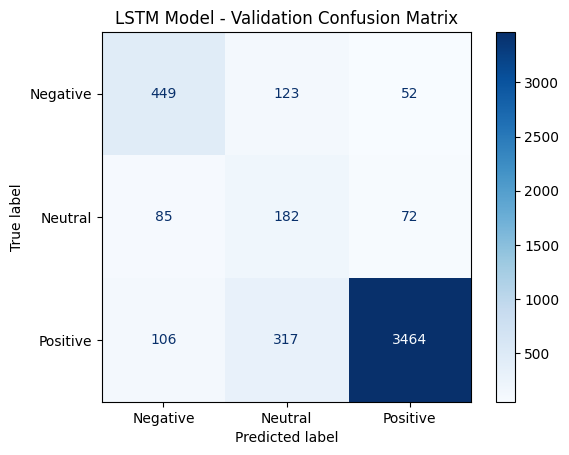

In [ ]:
cm_lstm = confusion_matrix(y_val, y_val_pred_lstm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(cmap="Blues")
plt.title("LSTM Model - Validation Confusion Matrix")
plt.show()

19.4 Store LSTM metrics

In [ ]:
lstm_accuracy = accuracy_score(
    y_val,
    y_val_pred_lstm
)

lstm_precision = precision_score(
    y_val,
    y_val_pred_lstm,
    average="macro"
)

lstm_recall = recall_score(
    y_val,
    y_val_pred_lstm,
    average="macro"
)

lstm_f1 = f1_score(
    y_val,
    y_val_pred_lstm,
    average="macro"
)

print("LSTM Validation Metrics")
print("-----------------------")
print(f"Accuracy:        {lstm_accuracy:.4f}")
print(f"Macro Precision: {lstm_precision:.4f}")
print(f"Macro Recall:    {lstm_recall:.4f}")
print(f"Macro F1-score:  {lstm_f1:.4f}")

LSTM Validation Metrics
-----------------------
Accuracy:        0.8443
Macro Precision: 0.6532
Macro Recall:    0.7159
Macro F1-score:  0.6720


19.5 Compare LSTM against baseline

In [ ]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Baseline", "LSTM"],
    "Accuracy": [
        baseline_accuracy,
        lstm_accuracy
    ],
    "Macro Precision": [
        baseline_precision,
        lstm_precision
    ],
    "Macro Recall": [
        baseline_recall,
        lstm_recall
    ],
    "Macro F1": [
        baseline_f1,
        lstm_f1
    ]
})

model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline,0.8414,0.6828,0.6671,0.6404
1,LSTM,0.8443,0.6532,0.7159,0.6720


20. Bidirectional LSTM Model

20.1 Build the BiLSTM

In [ ]:
from tensorflow.keras.layers import Bidirectional

tf.random.set_seed(42)

bilstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        3,
        activation="softmax"
    )
])

bilstm_model.build(input_shape=(None, max_length))

bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,354,499 (5.17 MB)

 Trainable params: 1,354,499 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

20.2 Compile the Model

In [ ]:
bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Bidirectional LSTM model compiled successfully.")

Bidirectional LSTM model compiled successfully.


20.3 Train the Model

In [ ]:
early_stopping_bilstm = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [ ]:
history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping_bilstm],
    verbose=1
)

Epoch 1/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 242s 388ms/step - accuracy: 0.7383 - loss: 0.7311 - val_accuracy: 0.8443 - val_loss: 0.4133
Epoch 2/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 235s 387ms/step - accuracy: 0.8453 - loss: 0.5211 - val_accuracy: 0.8361 - val_loss: 0.4086
Epoch 3/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 258s 381ms/step - accuracy: 0.8757 - loss: 0.4207 - val_accuracy: 0.8200 - val_loss: 0.4526
Epoch 4/15
607/607 ━━━━━━━━━━━━━━━━━━━━ 234s 386ms/step - accuracy: 0.9025 - loss: 0.3158 - val_accuracy: 0.8282 - val_loss: 0.4793


20.4 Plot accuracy and loss

Accuracy

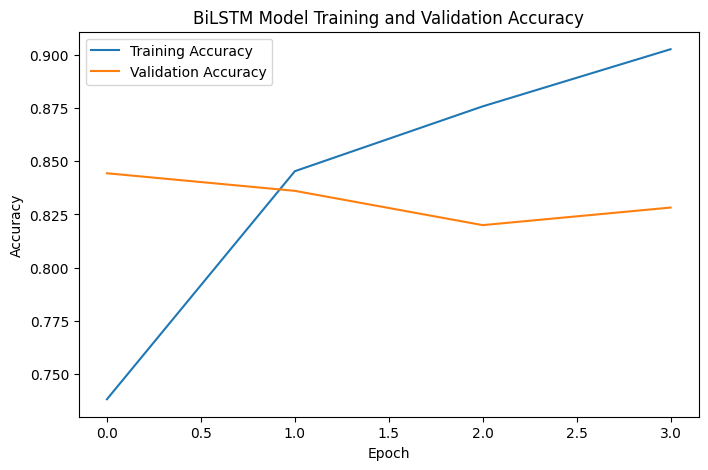

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_bilstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_bilstm.history["val_accuracy"], label="Validation Accuracy")

plt.title("BiLSTM Model Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Loss

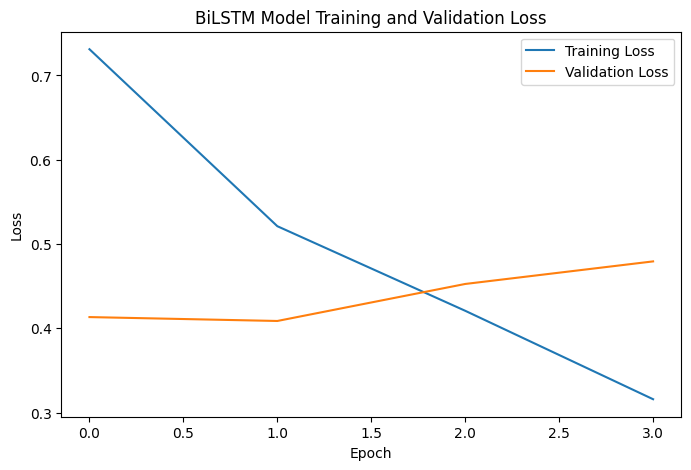

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_bilstm.history["loss"], label="Training Loss")
plt.plot(history_bilstm.history["val_loss"], label="Validation Loss")

plt.title("BiLSTM Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

21. BiLSTM Model Validation Evaluation

21.1 Generate predictions

In [ ]:
# Predict probabilities for validation data
y_val_prob_bilstm = bilstm_model.predict(X_val_pad)

# Convert probabilities to class labels
y_val_pred_bilstm = np.argmax(y_val_prob_bilstm, axis=1)

print("First 20 predicted labels:")
print(y_val_pred_bilstm[:20])

print("\nFirst 20 actual labels:")
print(y_val.iloc[:20].values)

152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step
First 20 predicted labels:
[2 2 2 2 2 1 2 2 2 2 2 1 2 2 2 2 2 2 1 2]

First 20 actual labels:
[2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2]


21.2 Classification report

In [ ]:
print("BiLSTM Model - Validation Classification Report:\n")

print(
    classification_report(
        y_val,
        y_val_pred_bilstm,
        target_names=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

BiLSTM Model - Validation Classification Report:

              precision    recall  f1-score   support

    Negative     0.7415    0.7356    0.7385       624
     Neutral     0.2829    0.6283    0.3901       339
    Positive     0.9727    0.8703    0.9187      3887

    accuracy                         0.8361      4850
   macro avg     0.6657    0.7447    0.6824      4850
weighted avg     0.8947    0.8361    0.8585      4850



21.3 Confusion matrix

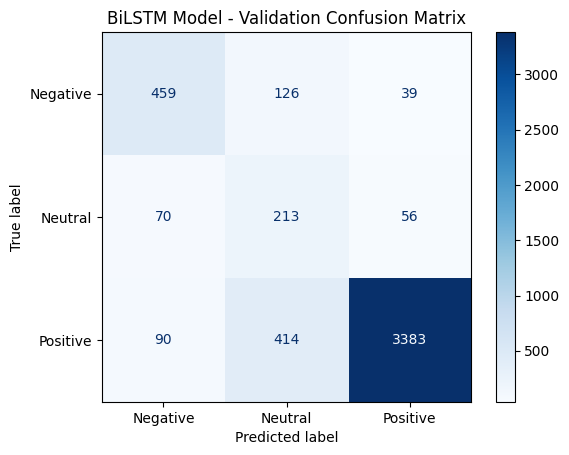

In [ ]:
cm_bilstm = confusion_matrix(y_val, y_val_pred_bilstm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bilstm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(cmap="Blues")
plt.title("BiLSTM Model - Validation Confusion Matrix")
plt.show()

21.4 Store the BiLSTM metrics

In [ ]:
bilstm_accuracy = accuracy_score(
    y_val,
    y_val_pred_bilstm
)

bilstm_precision = precision_score(
    y_val,
    y_val_pred_bilstm,
    average="macro"
)

bilstm_recall = recall_score(
    y_val,
    y_val_pred_bilstm,
    average="macro"
)

bilstm_f1 = f1_score(
    y_val,
    y_val_pred_bilstm,
    average="macro"
)

print("BiLSTM Validation Metrics")
print("-------------------------")
print(f"Accuracy:        {bilstm_accuracy:.4f}")
print(f"Macro Precision: {bilstm_precision:.4f}")
print(f"Macro Recall:    {bilstm_recall:.4f}")
print(f"Macro F1-score:  {bilstm_f1:.4f}")

BiLSTM Validation Metrics
-------------------------
Accuracy:        0.8361
Macro Precision: 0.6657
Macro Recall:    0.7447
Macro F1-score:  0.6824


21.5 Final validation comparison

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "LSTM",
        "BiLSTM"
    ],

    "Accuracy": [
        baseline_accuracy,
        lstm_accuracy,
        bilstm_accuracy
    ],

    "Macro Precision": [
        baseline_precision,
        lstm_precision,
        bilstm_precision
    ],

    "Macro Recall": [
        baseline_recall,
        lstm_recall,
        bilstm_recall
    ],

    "Macro F1": [
        baseline_f1,
        lstm_f1,
        bilstm_f1
    ]
})

model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline,0.8414,0.6828,0.6671,0.6404
1,LSTM,0.8443,0.6532,0.7159,0.6720
2,BiLSTM,0.8361,0.6657,0.7447,0.6824


22. Final Evaluation of the Selected BiLSTM Model

In [ ]:
# Generate predictions on the unseen test set
y_test_prob_bilstm = bilstm_model.predict(X_test_pad)

# Convert predicted probabilities into class labels
y_test_pred_bilstm = np.argmax(y_test_prob_bilstm, axis=1)

print("First 20 predicted test labels:")
print(y_test_pred_bilstm[:20])

print("\nFirst 20 actual test labels:")
print(y_test.iloc[:20].values)

152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step
First 20 predicted test labels:
[2 2 2 0 2 2 0 2 2 2 2 1 2 2 0 2 2 2 2 2]

First 20 actual test labels:
[1 2 2 0 2 2 0 2 2 1 2 0 0 2 2 2 2 0 2 2]


22.1 Test classification report

In [ ]:
print("BiLSTM Model - Test Classification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred_bilstm,
        target_names=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

BiLSTM Model - Test Classification Report:

              precision    recall  f1-score   support

    Negative     0.7479    0.7131    0.7301       624
     Neutral     0.2666    0.5929    0.3678       339
    Positive     0.9677    0.8717    0.9172      3888

    accuracy                         0.8318      4851
   macro avg     0.6607    0.7259    0.6717      4851
weighted avg     0.8905    0.8318    0.8547      4851



22.2 Test confusion matrix

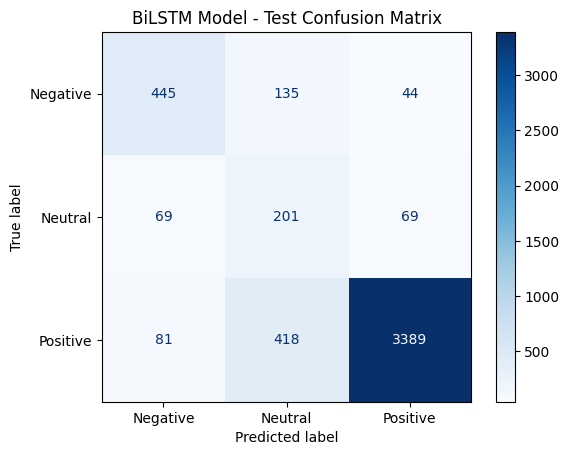

In [ ]:
cm_test_bilstm = confusion_matrix(
    y_test,
    y_test_pred_bilstm
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_bilstm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(cmap="Blues")
plt.title("BiLSTM Model - Test Confusion Matrix")
plt.show()

22.3 Store final test metrics

In [ ]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred_bilstm
)

test_precision = precision_score(
    y_test,
    y_test_pred_bilstm,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_test_pred_bilstm,
    average="macro"
)

test_f1 = f1_score(
    y_test,
    y_test_pred_bilstm,
    average="macro"
)

print("Final BiLSTM Test Metrics")
print("-------------------------")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1-score:  {test_f1:.4f}")

Final BiLSTM Test Metrics
-------------------------
Accuracy:        0.8318
Macro Precision: 0.6607
Macro Recall:    0.7259
Macro F1-score:  0.6717


22.4 Final Model Interpretation

The Bidirectional LSTM achieved a final test accuracy of 83.18% and a macro F1-score of 0.6717. These results are close to the validation accuracy of 83.61% and macro F1-score of 0.6824, indicating that the model generalised reasonably well to previously unseen reviews. Performance varied substantially between sentiment classes. Positive reviews achieved the strongest F1-score (0.9172), followed by Negative reviews (0.7301), while Neutral reviews were more difficult to classify (0.3678). The confusion matrix shows that 3,389 of 3,888 Positive reviews and 445 of 624 Negative reviews were correctly identified, whereas only 201 of 339 Neutral reviews were correctly classified. This reflects both the substantial class imbalance within the dataset and the greater ambiguity associated with neutral sentiment. Although the BiLSTM did not achieve the highest overall validation accuracy among the evaluated models, it was selected because it produced the strongest macro F1-score, providing a better balance of predictive performance across all three sentiment classes.